# Data Cleaning

Tolong baca perintah dan tagar komen dengan saksama.

Silahkan tulis analisa dan alasan anda membuat keputusan di dalam notebook ini, baik sebagai comment ataupun text markdown. Sertakan step analisis pendukung seperti plot distribusi, analisis deskriptif, dll yang terkait.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## A. Outlier Handling

Lakukan analisis outlier, dan hilangkan data pada kolom yang menurut anda mengandung outlier.

In [ ]:
df_california = pd.read_csv('california_dataset.csv')

In [ ]:
#cek data terlebih dahulu untuk mengetahui kolom dan datanya seperti apa
print(df_california.columns)
print(f"Number of data = {len(df_california)}")
df_california.head()

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'house_price'],
      dtype='object')
Number of data = 20640


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


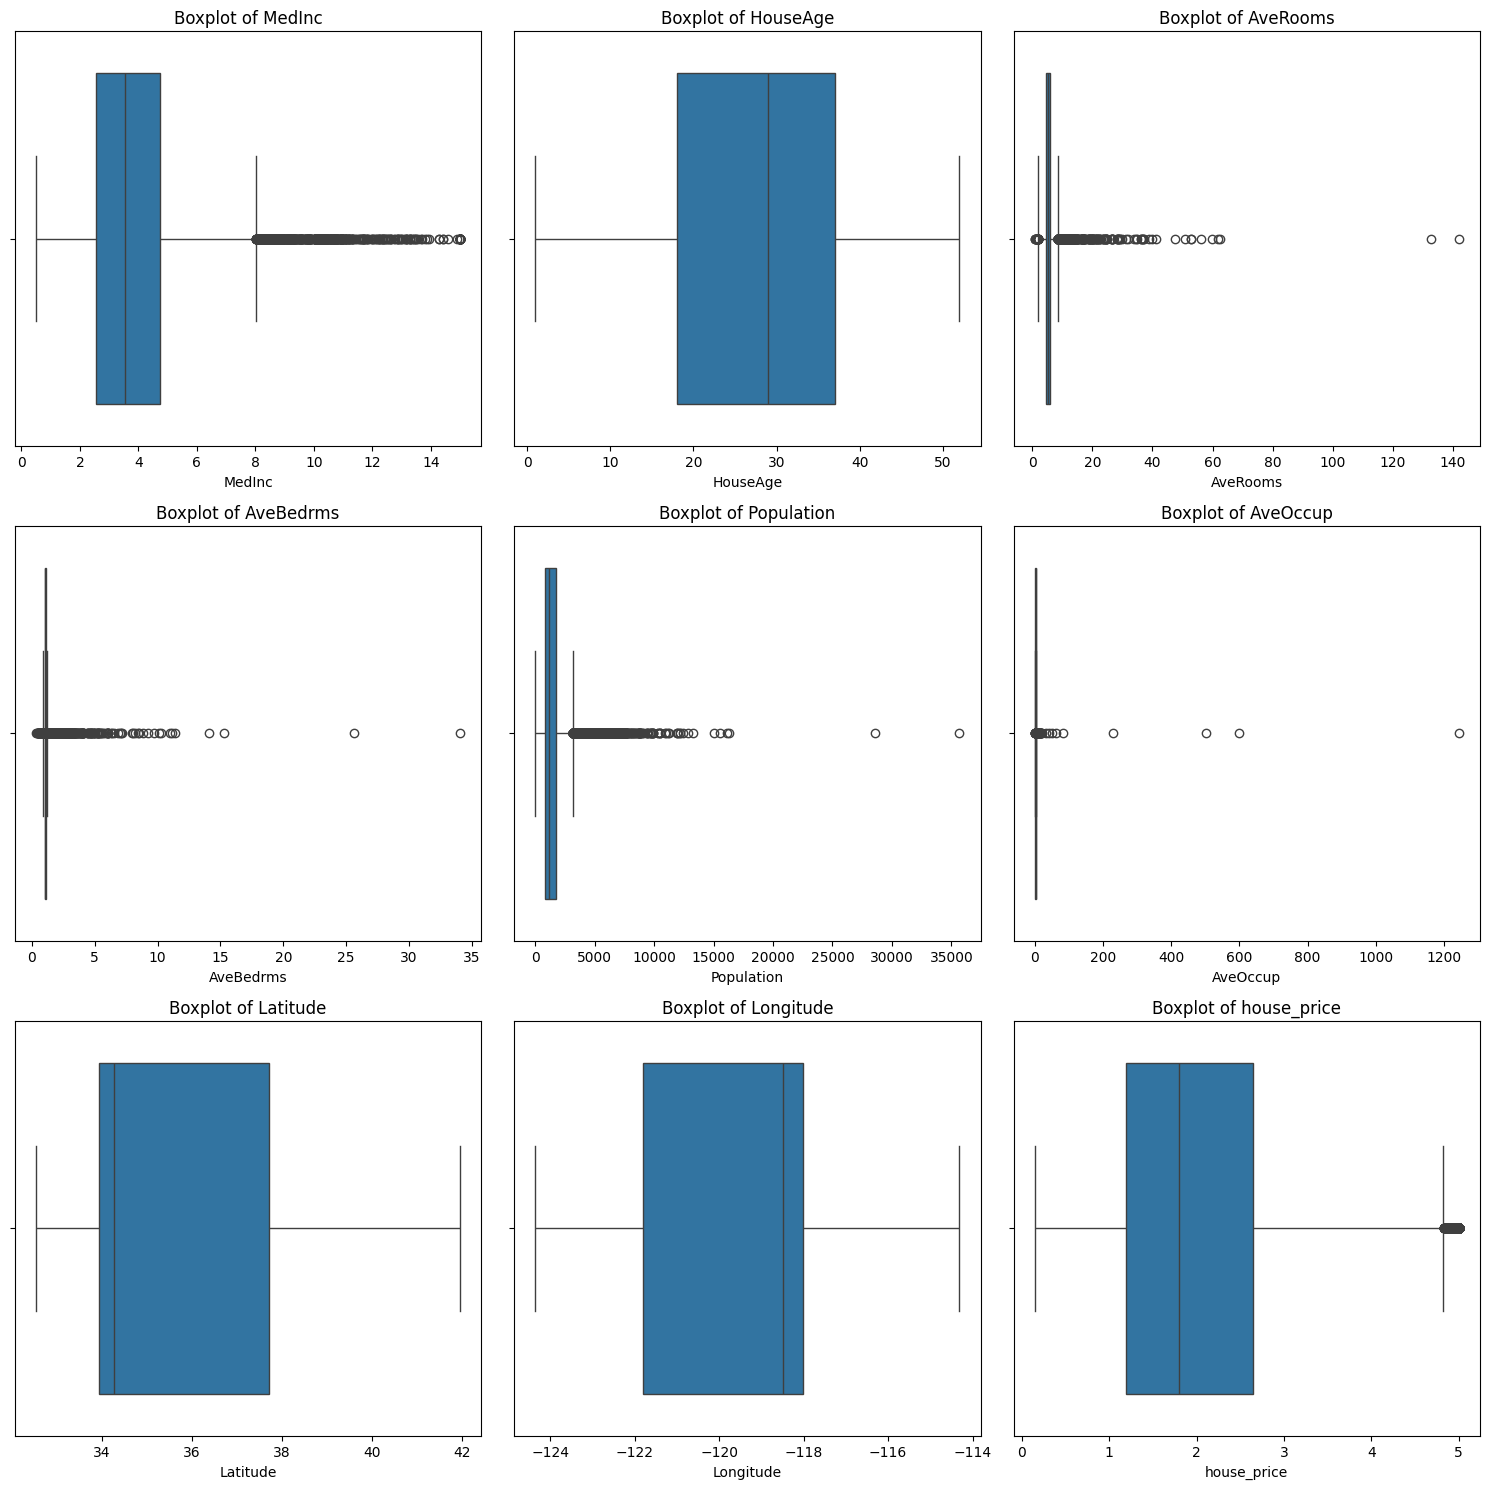

In [ ]:
#cek distribusi data menggunakan boxplot agar terlihat posisi titik outlier
california_plots = len(df_california.columns)
num_cols = 3
num_rows = (california_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()

for i, feature in enumerate(df_california.columns):
    sns.boxplot(x=df_california[feature], ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature}')

for i in range(california_plots, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#kalkulasi seberapa persen outlier setiap kolom
def calculate_outlier_pct(data, column):
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
  outlier_pct = (len(outliers) / len(data)) * 100
  return outlier_pct

outlier_pct = {}
for feature in df_california.columns:
  outlier_pct[feature] = calculate_outlier_pct(df_california, feature)

outlier_df = pd.DataFrame(
    {
        'Feature': outlier_pct.keys(),
        'Outlier Percentage': outlier_pct.values()
    }
)

outlier_df

,Feature,Outlier Percentage
0,MedInc,3.299419
1,HouseAge,0.000000
2,AveRooms,2.475775
3,AveBedrms,6.899225
4,Population,5.794574
5,AveOccup,3.444767
6,Latitude,0.000000
7,Longitude,0.000000
8,house_price,5.188953


Setelah melihat pada persentase di atas, outlier pada dataset california relatif kecil, beberapa ada yang di bawah 5% dan ada yang di atas 5%.
Maka dari itu, saya akan menggunakan metode IQR Capping, alasannya karena metode ini tidak membuang data tetapi membatasi nilai outlier agar tidak terlalu mempengaruhi model, sehingga distribusi data tetap terjaga dan model menjadi lebih stabil tanpa harus membuang data.

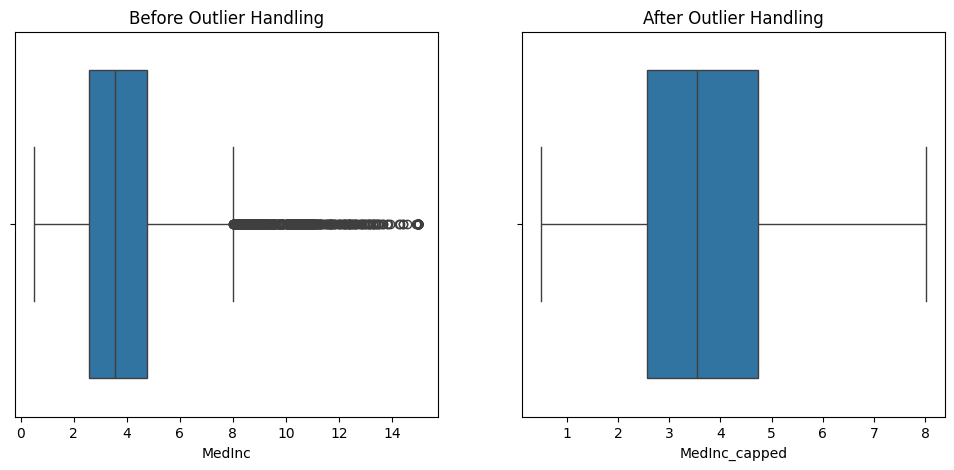

In [ ]:
#melakukan metode IQR Capping untuk outlier handling kolom MedInc
def calculate_iqr(data, column):
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  return lower_bound, upper_bound

lower, upper = calculate_iqr(df_california, "MedInc")

df_california["MedInc_capped"] = np.where(
    df_california["MedInc"] > upper, upper,
    np.where(df_california["MedInc"] < lower, lower, df_california["MedInc"])
)

#show before after iqr capping
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#before
sns.boxplot(x=df_california["MedInc"], ax=axes[0])
axes[0].set_title("Before Outlier Handling")

#after
sns.boxplot(x=df_california["MedInc_capped"], ax=axes[1])
axes[1].set_title("After Outlier Handling")

plt.show()

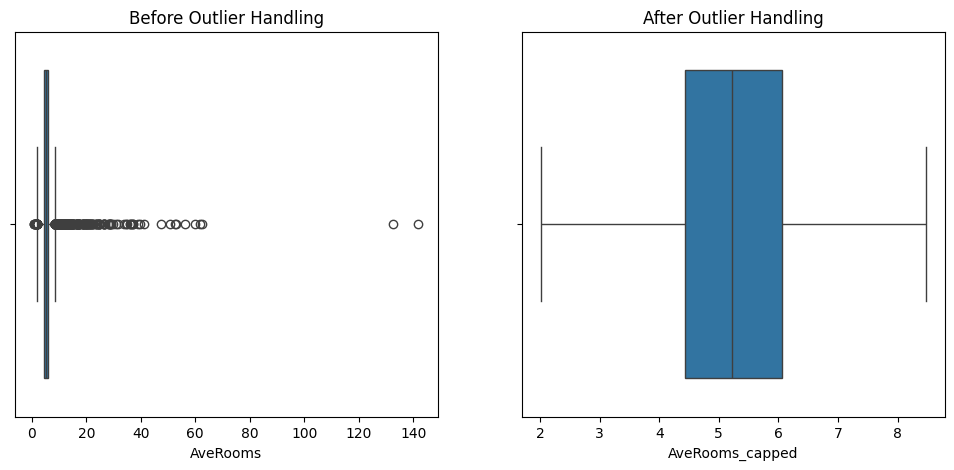

In [ ]:
#melakukan metode IQR Capping untuk outlier handling kolom AveRooms
lower, upper = calculate_iqr(df_california, "AveRooms")

df_california["AveRooms_capped"] = np.where(
    df_california["AveRooms"] > upper, upper,
    np.where(df_california["AveRooms"] < lower, lower, df_california["AveRooms"])
)

#show before after iqr capping
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#before
sns.boxplot(x=df_california["AveRooms"], ax=axes[0])
axes[0].set_title("Before Outlier Handling")

#after
sns.boxplot(x=df_california["AveRooms_capped"], ax=axes[1])
axes[1].set_title("After Outlier Handling")

plt.show()

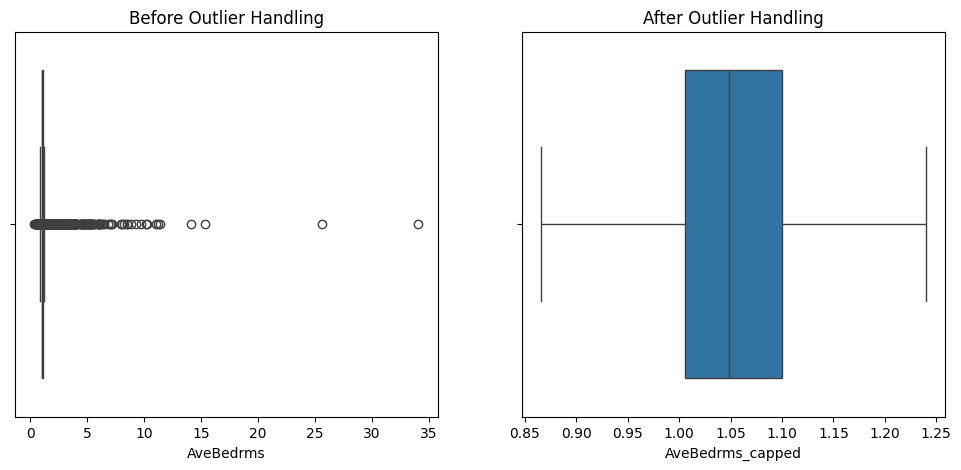

In [ ]:
#melakukan metode IQR Capping untuk outlier handling kolom AveBedrms
lower, upper = calculate_iqr(df_california, "AveBedrms")

df_california["AveBedrms_capped"] = np.where(
    df_california["AveBedrms"] > upper, upper,
    np.where(df_california["AveBedrms"] < lower, lower, df_california["AveBedrms"])
)

#show before after iqr capping
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#before
sns.boxplot(x=df_california["AveBedrms"], ax=axes[0])
axes[0].set_title("Before Outlier Handling")

#after
sns.boxplot(x=df_california["AveBedrms_capped"], ax=axes[1])
axes[1].set_title("After Outlier Handling")

plt.show()

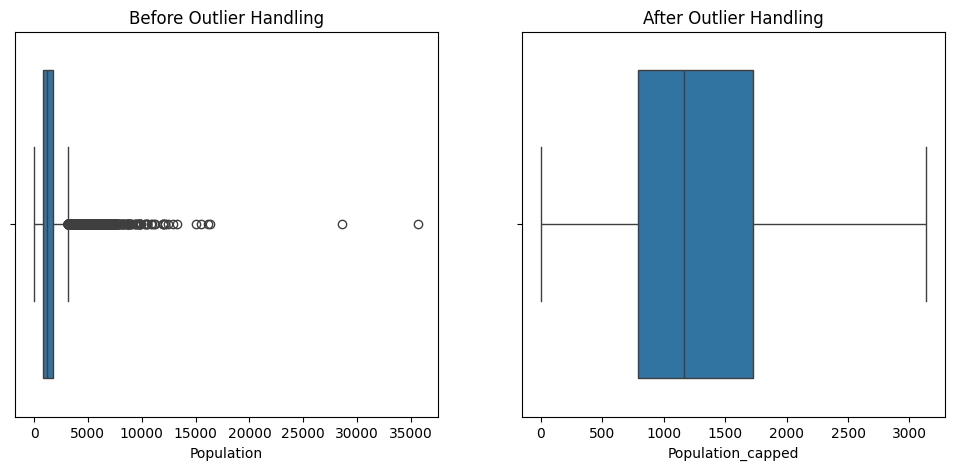

In [ ]:
#melakukan metode IQR Capping untuk outlier handling kolom Population
lower, upper = calculate_iqr(df_california, "Population")

df_california["Population_capped"] = np.where(
    df_california["Population"] > upper, upper,
    np.where(df_california["Population"] < lower, lower, df_california["Population"])
)

#show before after iqr capping
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#before
sns.boxplot(x=df_california["Population"], ax=axes[0])
axes[0].set_title("Before Outlier Handling")

#after
sns.boxplot(x=df_california["Population_capped"], ax=axes[1])
axes[1].set_title("After Outlier Handling")

plt.show()

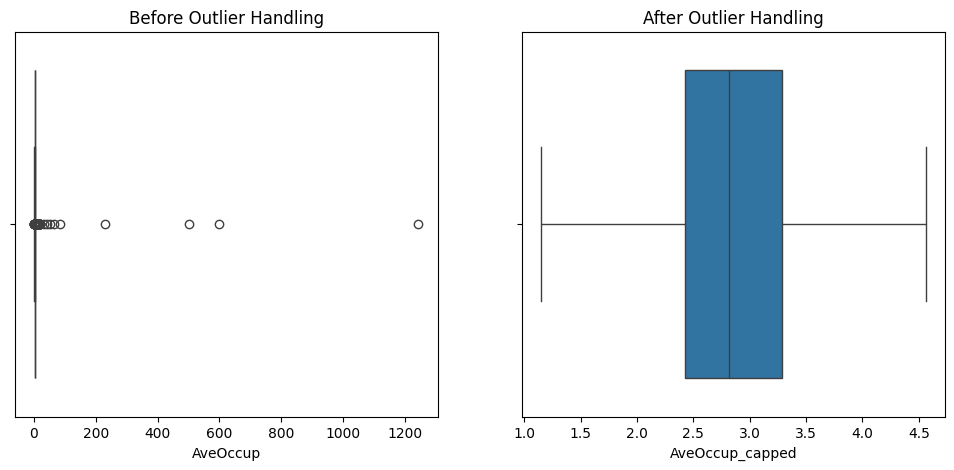

In [ ]:
#melakukan metode IQR Capping untuk outlier handling kolom AveOccup
lower, upper = calculate_iqr(df_california, "AveOccup")

df_california["AveOccup_capped"] = np.where(
    df_california["AveOccup"] > upper, upper,
    np.where(df_california["AveOccup"] < lower, lower, df_california["AveOccup"])
)

#show before after iqr capping
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#before
sns.boxplot(x=df_california["AveOccup"], ax=axes[0])
axes[0].set_title("Before Outlier Handling")

#after
sns.boxplot(x=df_california["AveOccup_capped"], ax=axes[1])
axes[1].set_title("After Outlier Handling")

plt.show()

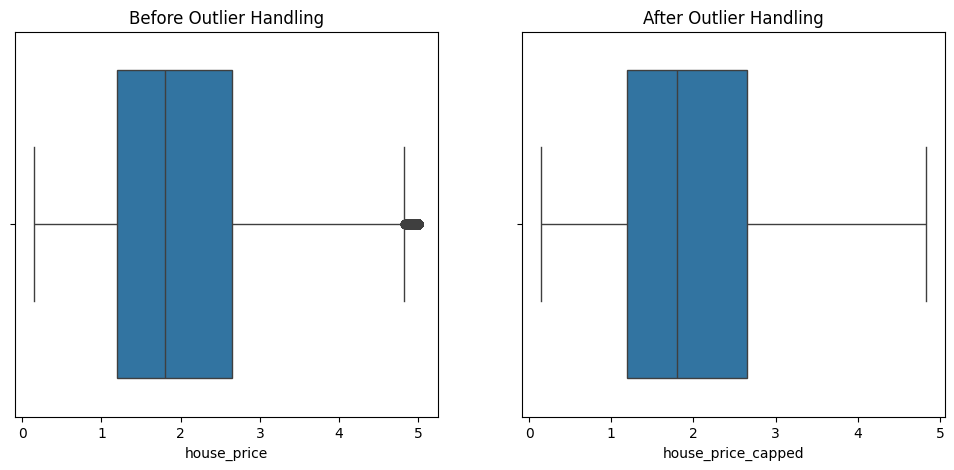

In [ ]:
#melakukan metode IQR Capping untuk outlier handling kolom house_price
lower, upper = calculate_iqr(df_california, "house_price")

df_california["house_price_capped"] = np.where(
    df_california["house_price"] > upper, upper,
    np.where(df_california["house_price"] < lower, lower, df_california["house_price"])
)

#show before after iqr capping
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#before
sns.boxplot(x=df_california["house_price"], ax=axes[0])
axes[0].set_title("Before Outlier Handling")

#after
sns.boxplot(x=df_california["house_price_capped"], ax=axes[1])
axes[1].set_title("After Outlier Handling")

plt.show()

In [ ]:
#cek persentase outlier setelah melakukan metode IQR capping
outlier_pct = {}

for feature in df_california.columns:
  outlier_pct[feature] = calculate_outlier_pct(df_california, feature)

outlier_df = pd.DataFrame(
    {
        'Feature': outlier_pct.keys(),
        'Outlier Percentage': outlier_pct.values()
    }
)

outlier_df

,Feature,Outlier Percentage
0,MedInc,3.299419
1,HouseAge,0.000000
2,AveRooms,2.475775
3,AveBedrms,6.899225
4,Population,5.794574
5,AveOccup,3.444767
6,Latitude,0.000000
7,Longitude,0.000000
8,house_price,5.188953
9,MedInc_capped,0.000000


## B. Missing Value Handling

Lakukan analisis missing valye, dan lakukan treatment apapun terhadap missing values tersebut yang anda nilai sesuai.

In [ ]:
df_company = pd.read_csv('company.csv')

In [ ]:
#cek data terlebih dahulu untuk mengetahui kolom dan datanya seperti apa
print(df_company.columns)
print(f"Number of data = {len(df_company)}")
df_company.head()

Index(['Revenue', 'Size', 'Rating', 'Headquarters'], dtype='object')
Number of data = 672


,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,NaN,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"


In [ ]:
#cek berapa banyak missing value
missing_values = df_company.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_pct = (missing_values / len(df_company)) * 100
missing_data = pd.DataFrame(
    {
        'Missing Values' : missing_values,
        'Percentage' : missing_pct
    }
)
missing_data

,Missing Values,Percentage
Rating,50,7.440476


In [ ]:
#cek value counts setiap kolom karena pada kolom Revenue ada data 'Unknown / Non-Applicable'
#yang tidak dihitung oleh pandas
df_company['Revenue'].value_counts()

,count
Revenue,
Unknown / Non-Applicable,213
$100 to $500 million (USD),94
$10+ billion (USD),63
$2 to $5 billion (USD),45
$10 to $25 million (USD),41
$1 to $2 billion (USD),36
$25 to $50 million (USD),36
$50 to $100 million (USD),31
$1 to $5 million (USD),31


In [ ]:
df_company['Rating'].value_counts()

,count
Rating,
3.5,52
-1.0,43
3.3,39
3.9,39
4.0,38
3.7,37
3.8,35
5.0,34
4.5,31


In [ ]:
df_company['Size'].value_counts()

,count
Size,
51 to 200 employees,135
1001 to 5000 employees,104
1 to 50 employees,86
201 to 500 employees,85
10000+ employees,80
501 to 1000 employees,77
5001 to 10000 employees,61
-1,27
Unknown,17


In [ ]:
df_company['Headquarters'].value_counts()

,count
Headquarters,
"New York, NY",33
"San Francisco, CA",31
-1,31
"Chicago, IL",23
"Boston, MA",19
"Reston, VA",14
"Mc Lean, VA",13
"Westminster, CO",12
"Cambridge, MA",10


Setelah melihat value counts di atas, banyak data seperti '-1' dan 'Unknown' yang tidak terdeteksi sebagai missing value.
Maka langkah selanjutnya adalah merename '-1' dan 'Unknown' menjadi 'NaN'

In [ ]:
#rename missing value
df_company = df_company.replace({
    'Revenue': ['Unknown / Non-Applicable', '-1'],
    'Rating': [-1.0],
    'Size': ['-1', 'Unknown'],
    'Headquarters': ['-1']
}, np.nan)

#cek kembali jumlah missing value
missing_values = df_company.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_pct = (missing_values / len(df_company)) * 100
missing_data = pd.DataFrame(
    {
        'Missing Values' : missing_values,
        'Percentage' : missing_pct
    }
)
missing_data

,Missing Values,Percentage
Revenue,240,35.714286
Size,44,6.547619
Rating,93,13.839286
Headquarters,31,4.613095


In [ ]:
#memisahkan tipe data untuk menentukan treatment missing valuenya

categorical_features = [
    'Revenue',
    'Size',
    'Headquarters'
]

numerical_features =['Rating']

Setelah melihat persentase missing value, saya akan melakukan treatment sebagai berikut :
- Revenue =  kolom tersebut adalah kolom categorical maka saya akan menambah kategori baru yaitu 'Unknown' karena proporsi persentase missing value cukup besar (35%), sehingga tidak mengganggu distribusi data jika drop/imputasi
- Size = kolom tersebut adalah kolom categorical maka saya akan mengisinya dengan mode karena representatif dan tidak banyak mempengaruhi distribusi datanya
- Rating = kolom tersebut adalah kolom numerical maka saya akan menggunakan KNN Imputer karena rating memiliki relasi dengan kolom lain
- Headquarters =  kolom tersebut adalah kolom categorical maka saya akan menambah kategori baru yaitu 'Unknown' karena mengisi dengan mode bisa menempelkan lokasi yang salah ke perusahaan

In [ ]:
#treatment missing value - Revenue
df_company['Revenue'] = df_company['Revenue'].fillna('Unknown')

#treatment missing value - Size
df_company['Size'] = df_company['Size'].fillna(df_company['Size'].mode().iloc[0])

#treatment missing value - Rating
imputer = KNNImputer(n_neighbors=4)
df_company[["Rating"]] = imputer.fit_transform(df_company[["Rating"]])

#treatment missing value - Headquarters
df_company['Headquarters'] = df_company['Headquarters'].fillna('Unknown')

#cek kembali missing data
missing_values = df_company.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_pct = (missing_values / len(df_company)) * 100
missing_data = pd.DataFrame(
    {
        'Missing Values' : missing_values,
        'Percentage' : missing_pct
    }
)
missing_data

,Missing Values,Percentage


## C. Encoding

Lakukan analisis terhadap data, dan lakukan label encoding atau on-hot encoding terhadap kolom kategorical-nya.

Silahkan tentukan sendiri teknik encoding yang sesuai.

In [ ]:
df_churn = pd.read_csv('Telco_customer_churn.csv')

In [ ]:
#cek data terlebih dahulu untuk mengetahui kolom dan datanya seperti apa
print(df_churn.columns)
print(f"Number of data = {len(df_churn)}")
df_churn.head()

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')
Number of data = 7043


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
#cek unique valuesnya
for col in df_churn.columns:
    print(f"Unique Values {col}")
    print(df_churn[col].unique())
    print()


Unique Values CustomerID
['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']

Unique Values Count
[1]

Unique Values Country
['United States']

Unique Values State
['California']

Unique Values City
['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley']

Unique Values Zip Code
[90003 90005 90006 ... 96128 96134 96146]

Unique Values Lat Long
['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401']

Unique Values Latitude
[33.964131 34.059281 34.048013 ... 40.346634 41.813521 39.191797]

Unique Values Longitude
[-118.272783 -118.30742  -118.293953 ... -120.386422 -121.492666
 -120.212401]

Unique Values Gender
['Male' 'Female']

Unique Values Senior Citizen
['No' 'Yes']

Unique Values Partner
['No' 'Yes']

Unique Values Dependents
['No' 'Yes']

Unique Values Tenure Months
[ 2  8 28 49 10  1 47 17  5 34 11 15 18  9  7 

In [ ]:
#pisah kolom numerical dan categorical
numerical_features = [
  'Zip Code',
  'Lat Long',
  'Latitude',
  'Longitude',
  'Tenure Months',
  'Monthly Charges',
  'Total Charges',
  'Churn Value',
  'Churn Score',
  'CLTV'
]

categorical_features = [
    'CustomerID',
    'Country',
    'State',
    'City',
    'Gender',
    'Senior Citizen',
    'Partner',
    'Dependents',
    'Phone Service',
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Online Backup',
    'Device Protection',
    'Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Contract',
    'Paperless Billing',
    'Payment Method',
    'Churn Label',
    'Churn Reason'
]

Setelah melihat unique value masing masing kolom categorical, maka saya akan melakukan hal sebagai berikut :
- CustomerID = Setiap datanya unik sehingga jika diubah ke encoding akan panjang, untuk kolom ini bisa kita drop atau abaikan
- Country = Binary Encoding karena datanya hanya 1
- State = Binary Encoding karena datanya hanya 1
- City= Label Encoding karena datanya cukup banyak
- Gender = Binary Encoding karena datanya hanya 2
- Senior Citizen = Binary Encoding karena datanya hanya 2
- Partner = Binary Encoding karena datanya hanya 2
- Dependents = Binary Encoding karena datanya hanya 2
- Phone Service = Binary Encoding karena datanya hanya 2
- Multiple Line = One Hot Encoding karena unique value masih di bawah 5, sehingga tidak terlalu banyak angka 0
- Internet Service = One Hot Encoding karena unique value masih di bawah 5, sehingga tidak terlalu banyak angka 0
- Online Security = One Hot Encoding karena unique value masih di bawah 5, sehingga tidak terlalu banyak angka 0
- Online Backup = One Hot Encoding karena unique value masih di bawah 5, sehingga tidak terlalu banyak angka 0
- Device Protection = One Hot Encoding karena unique value masih di bawah 5, sehingga tidak terlalu banyak angka 0
- Tech Support = One Hot Encoding karena unique value masih di bawah 5, sehingga tidak terlalu banyak angka 0
- Streaming TV = One Hot Encoding karena unique value masih di bawah 5, sehingga tidak terlalu banyak angka 0
- Streaming Movies = One Hot Encoding karena unique value masih di bawah 5, sehingga tidak terlalu banyak angka 0
- Contract = One Hot Encoding karena unique value masih di bawah 5, sehingga tidak terlalu banyak angka 0
- Paperless Billing = Binary Encoding karena datanya hanya 2
- Payment Method = One Hot Encoding karena unique value masih di bawah 5, sehingga tidak terlalu banyak angka 0
- Churn Label = Binary Encoding karena datanya hanya 2
- Churn Reason = Label Encoding karena datanya cukup banyak

In [ ]:
#pisahkan sesuai encodingnya
binary_cols = ['Country', 'State', 'Gender', 'Partner', 'Dependents',
               'Senior Citizen', 'Phone Service', 'Paperless Billing',
               'Churn Label']

onehot_cols = ['Multiple Lines', 'Internet Service',
               'Online Security', 'Online Backup',
               'Device Protection', 'Tech Support',
               'Streaming TV', 'Streaming Movies',
               'Contract', 'Payment Method']

label_cols = ['City', 'Churn Reason']

#binary encoding
for col in binary_cols:
  if col in df_churn.columns:
    if col == 'Country':
      df_churn[col] = df_churn[col].apply(lambda x: 1 if x == 'United States' else 0)
    elif col == 'State':
      df_churn[col] = df_churn[col].apply(lambda x: 1 if x == 'California' else 0)
    elif col == 'Gender':
      df_churn[col] = df_churn[col].map({'Male': 1, 'Female': 0})
    else:
      df_churn[col] = df_churn[col].map({'Yes': 1, 'No': 0})

#one hot encoding
df_churn = pd.get_dummies(df_churn, columns=onehot_cols, prefix=onehot_cols, drop_first=True)

#label encoding
le = LabelEncoder()
for col in label_cols:
  df_churn[col] = le.fit_transform(df_churn[col])

In [ ]:
#cek hasilnya
df_churn.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Multiple Lines_No phone service,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,Online Security_No internet service,Online Security_Yes,Online Backup_No internet service,Online Backup_Yes,Device Protection_No internet service,Device Protection_Yes,Tech Support_No internet service,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,3668-QPYBK,1,1,1,562,90003,"33.964131, -118.272783",33.964131,-118.272783,1,0,0,0,2,1,1,53.85,108.15,1,1,86,3239,3,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
1,9237-HQITU,1,1,1,562,90005,"34.059281, -118.30742",34.059281,-118.307420,0,0,0,1,2,1,1,70.70,151.65,1,1,67,2701,13,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,9305-CDSKC,1,1,1,562,90006,"34.048013, -118.293953",34.048013,-118.293953,0,0,0,1,8,1,1,99.65,820.5,1,1,86,5372,13,False,True,True,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False
3,7892-POOKP,1,1,1,562,90010,"34.062125, -118.315709",34.062125,-118.315709,0,0,1,1,28,1,1,104.80,3046.05,1,1,84,5003,13,False,True,True,False,False,False,False,False,False,True,False,True,False,True,False,True,False,False,False,True,False
4,0280-XJGEX,1,1,1,562,90015,"34.039224, -118.266293",34.039224,-118.266293,1,0,0,1,49,1,1,103.70,5036.3,1,1,89,5340,2,False,True,True,False,False,False,False,True,False,True,False,False,False,True,False,True,False,False,False,False,False


## D. Numeric Scaling

Analisis distirbusi dan min/max dari feature, dan lakukan min-max scaling serta standard scaling pada features tersebut.

Lakukan kedua teknik scaling. Pilih bebas feature mana untuk standard scaling, dan mana untuk min-max scaling.

In [ ]:
#df_california = pd.read_csv('california_dataset.csv')

In [ ]:
#cek data terlebih dahulu untuk mengetahui kolom dan datanya seperti apa
print(df_california.columns)
print(f"Number of data = {len(df_california)}")
df_california.head()

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'house_price', 'MedInc_capped',
       'AveRooms_capped', 'AveBedrms_capped', 'Population_capped',
       'AveOccup_capped', 'house_price_capped'],
      dtype='object')
Number of data = 20640


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price,MedInc_capped,AveRooms_capped,AveBedrms_capped,Population_capped,AveOccup_capped,house_price_capped
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,8.013025,6.984127,1.023810,322.0,2.555556,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,8.013025,6.238137,0.971880,2401.0,2.109842,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,7.257400,8.288136,1.073446,496.0,2.802260,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,5.643100,5.817352,1.073059,558.0,2.547945,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,3.846200,6.281853,1.081081,565.0,2.181467,3.422


In [ ]:
#pisahkan kolom numericalnya dan ambil 'capped' yang sudah bersih dari outlier
#saya akan take out latitude & longitude karena isi datanya merupakan titik koordinasi
numerical_features = [
    'MedInc_capped',
    'HouseAge',
    'AveRooms_capped',
    'AveBedrms_capped',
    'Population_capped',
    'AveOccup_capped',
    'house_price_capped'
]

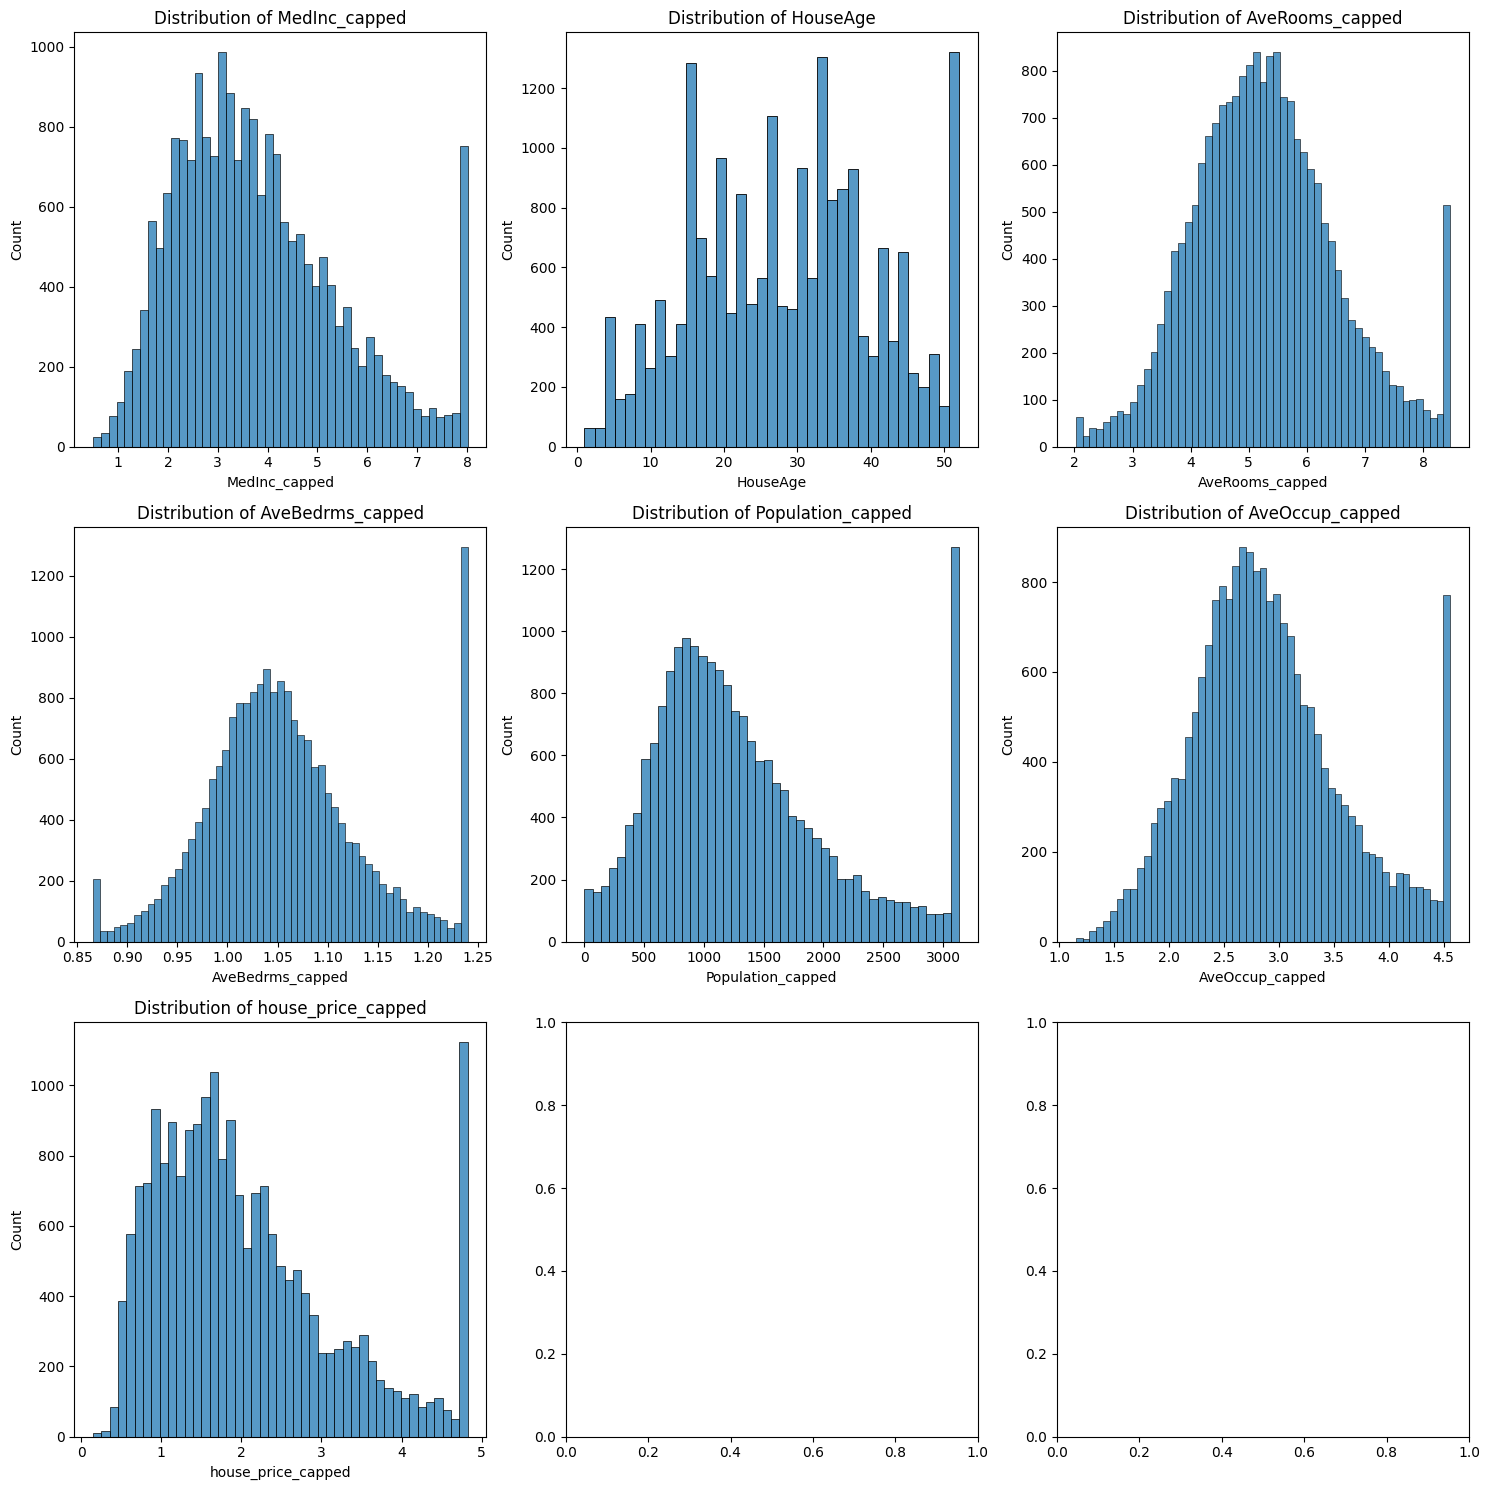

In [ ]:
#cek distribusi datanya
num_plots = len(numerical_features)
ncols = 3
nrows = (num_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))

for i, feature in enumerate(numerical_features):
  row = i // ncols
  col = i % ncols
  sns.histplot(df_california[feature], ax=axes[row, col])
  axes[row, col].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

Dari distribusi data di atas dapat kita simpulkan metode scaler yang akan digunakan. Untuk distribusi right skewed/left skewed akan menggunakan MinMaxScaler karena MinMax Scaler menjaga proporsi/distribusi data tanpa membuat nilai ekstrem terlalu berpengaruh, sedangkan untuk normal distribution akan memakai Standard Scaler karena Standard Scaler cocok untuk normal distribution dan menstandarkan nilai menjadi z-score sehingga menjaga proporsi data di sekitar rata-rata agar tidak bias.

Kolom yang memakai MinMax Scaler = 'MedInc_capped', 'HouseAge','Population_capped', 'house_price_capped'
    
Kolom yang memakai Standard Scaler = 'AveRooms_capped', 'AveBedrms_capped', 'AveOccup_capped'

In [ ]:
#membuat scaler
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

#memisahkan kolom yang menggunakan minmax & standard scaler
minmax_cols = ['MedInc_capped', 'HouseAge', 'Population_capped', 'house_price_capped']
standard_cols = ['AveRooms_capped', 'AveBedrms_capped', 'AveOccup_capped']

#memulai scaling
df_california[minmax_cols] = minmax_scaler.fit_transform(df_california[minmax_cols])
df_california[standard_cols] = standard_scaler.fit_transform(df_california[standard_cols])

In [ ]:
#print hasil minmax scaling
df_california[minmax_cols].head()

,MedInc_capped,HouseAge,Population_capped,house_price_capped
0,1.000000,0.784314,0.101950,0.936218
1,1.000000,0.392157,0.766379,0.734897
2,0.899426,1.000000,0.157558,0.721205
3,0.684562,1.000000,0.177373,0.698099
4,0.445394,1.000000,0.179610,0.700025


In [ ]:
#print hasil standard scaling
df_california[standard_cols].head()

,AveRooms_capped,AveBedrms_capped,AveOccup_capped
0,1.347665,-0.424488,-0.497871
1,0.749027,-1.070004,-1.142781
2,2.394098,0.192534,-0.140910
3,0.411358,0.187723,-0.508882
4,0.784108,0.287439,-1.039145


## E. Lainnya

Pilihlah salah satu dataset dari ketiga dataset yang diberikan. Analisis lebih lanjut data tersebut, dan lakukan data cleaning lainnya yang menurut anda diperlukan.

Menurut saya, data cleaning yang harus dilakukan adalah membersihkan data duplicate dan saya akan menggunakan data csv company

In [ ]:
#cek berapa banyak data duplicate
duplicate_rows = df_company[df_company.duplicated()]
print(f"Number of duplicate rows: {len(duplicate_rows)}")

Number of duplicate rows: 236


In [ ]:
#membersihkan data duplicate
print(f"Number of data before removing duplicates= 672")
data = df_company.drop_duplicates()
print(f"Number of data after removing duplicates= {len(data)}")

Number of data before removing duplicates= 672
Number of data after removing duplicates= 436
